In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

OUTPUT_DIR = "output_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
from google.colab import files

uploaded = files.upload()
image_paths = list(uploaded.keys())
print("Gambar yang berhasil diupload:", image_paths)

Saving gradient_halus.png to gradient_halus.png
Saving gravel_tekstur_halus.png to gravel_tekstur_halus.png
Saving astronaut_detail_wajah.png to astronaut_detail_wajah.png
Saving checkerboard_tepi_tajam.png to checkerboard_tepi_tajam.png
Gambar yang berhasil diupload: ['gradient_halus.png', 'gravel_tekstur_halus.png', 'astronaut_detail_wajah.png', 'checkerboard_tepi_tajam.png']


In [5]:
def load_image_rgb(path, max_dim=512):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    scale = min(max_dim / max(h, w), 1.0) if max(h, w) > max_dim else 1.0
    new_h, new_w = int(h * scale), int(w * scale)
    #bulatkan ke kelipatan 8 agar habis dibagi faktor downsampling (2, 4, 8)
    new_h = (new_h // 8) * 8
    new_w = (new_w // 8) * 8
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return img

images = {}
for p in image_paths:
    name = os.path.splitext(p)[0]
    images[name] = load_image_rgb(p)
    print(f"{name}: shape = {images[name].shape}")

gradient_halus: shape = (512, 512, 3)
gravel_tekstur_halus: shape = (512, 512, 3)
astronaut_detail_wajah: shape = (512, 512, 3)
checkerboard_tepi_tajam: shape = (200, 200, 3)


# Fungsi Down Sampling

Down sampling dilakukan dengan pendekatan block-based pooling: citra dibagi menjadiblok-blok berukuran factor x factor, lalu setiap blok direduksi menjadi satu piksel menggunakan operasi statistik tertentu (max, rata-rata, atau median).

In [6]:
def downsample_max(img, factor):
    """Down sampling dengan Max Pooling"""
    h, w = img.shape[:2]
    new_h, new_w = h // factor, w // factor
    if img.ndim == 3:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
    else:
        out = np.zeros((new_h, new_w), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            block = img[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
            out[i, j] = block.max(axis=(0, 1)) if img.ndim == 3 else block.max()
    return out


def downsample_average(img, factor):
    """Down sampling dengan Average Pooling"""
    h, w = img.shape[:2]
    new_h, new_w = h // factor, w // factor
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)


def downsample_median(img, factor):
    """Down sampling dengan Median Pooling"""
    h, w = img.shape[:2]
    new_h, new_w = h // factor, w // factor
    if img.ndim == 3:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)
    else:
        out = np.zeros((new_h, new_w), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            block = img[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
            if img.ndim == 3:
                out[i, j] = np.median(block.reshape(-1, block.shape[2]), axis=0)
            else:
                out[i, j] = np.median(block)
    return out

#Fungsi Up Sampling

Up sampling mengembalikan citra ke ukuran semula menggunakan tiga metode interpolasi yang tersedia di OpenCV: Nearest Neighbor, Bilinear, dan Bicubic.

In [7]:
def upsample(img, target_size, method='nn'):
    """target_size = (width, height). method: 'nn', 'bilinear', 'bicubic'"""
    interp_map = {
        'nn': cv2.INTER_NEAREST,
        'bilinear': cv2.INTER_LINEAR,
        'bicubic': cv2.INTER_CUBIC
    }
    return cv2.resize(img, target_size, interpolation=interp_map[method])

#Fungsi Evaluasi & Visualisasi

In [8]:
def compute_metrics(original, reconstructed):
    """Menghitung MSE, PSNR, dan SSIM antara citra asli dan citra hasil rekonstruksi"""
    mse = np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)
    p = psnr(original, reconstructed, data_range=255)
    s = ssim(original, reconstructed, channel_axis=2, data_range=255)
    return {"MSE": mse, "PSNR": p, "SSIM": s}


def show_row(images_list, titles, suptitle, save_name=None):
    n = len(images_list)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images_list, titles):
        ax.imshow(im)
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    if save_name:
        fig.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=120, bbox_inches="tight")
    plt.show()

#Eksperimen Down Sampling

Untuk setiap gambar, dilakukan down sampling dengan faktor 4x menggunakan
Max, Average, dan Median Pooling, kemudian dibandingkan secara visual.

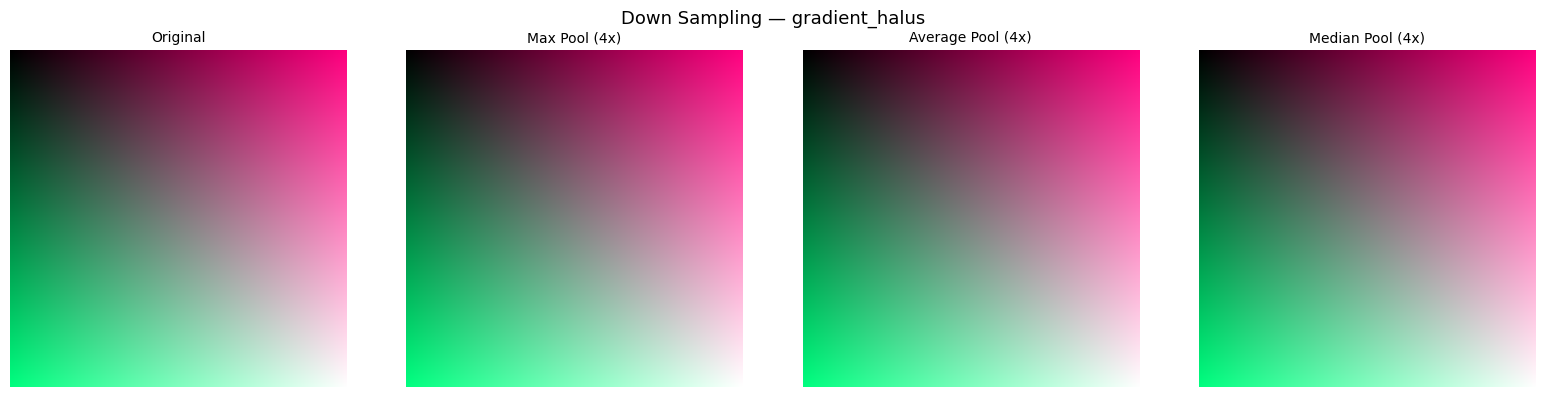

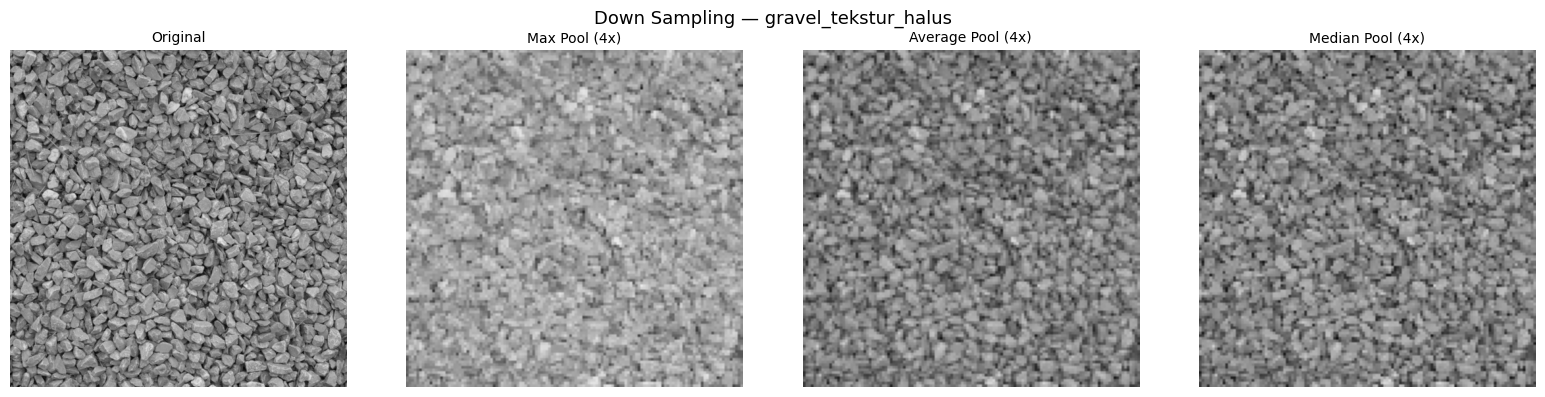

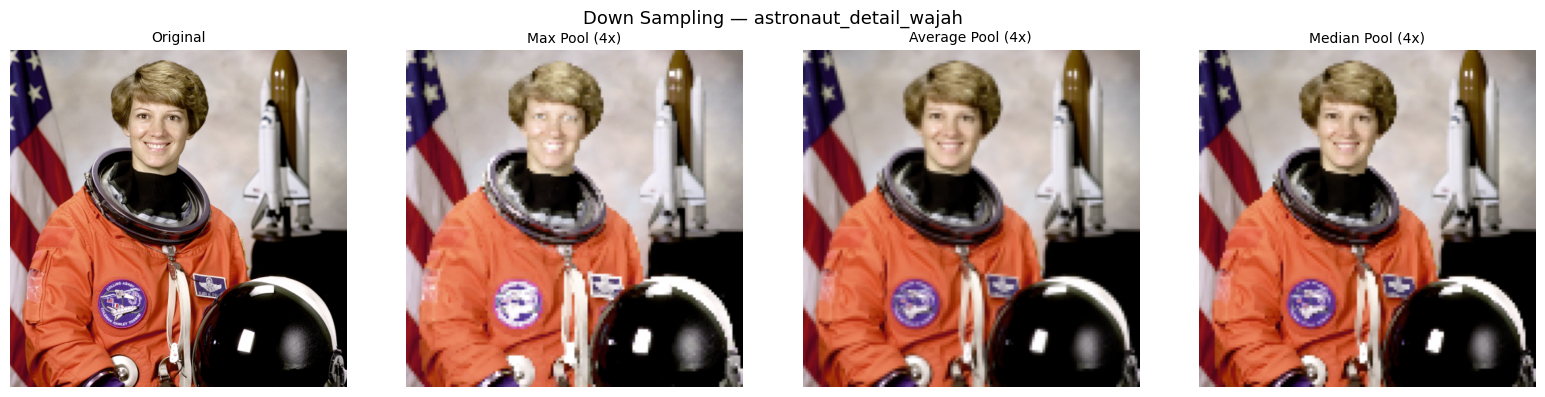

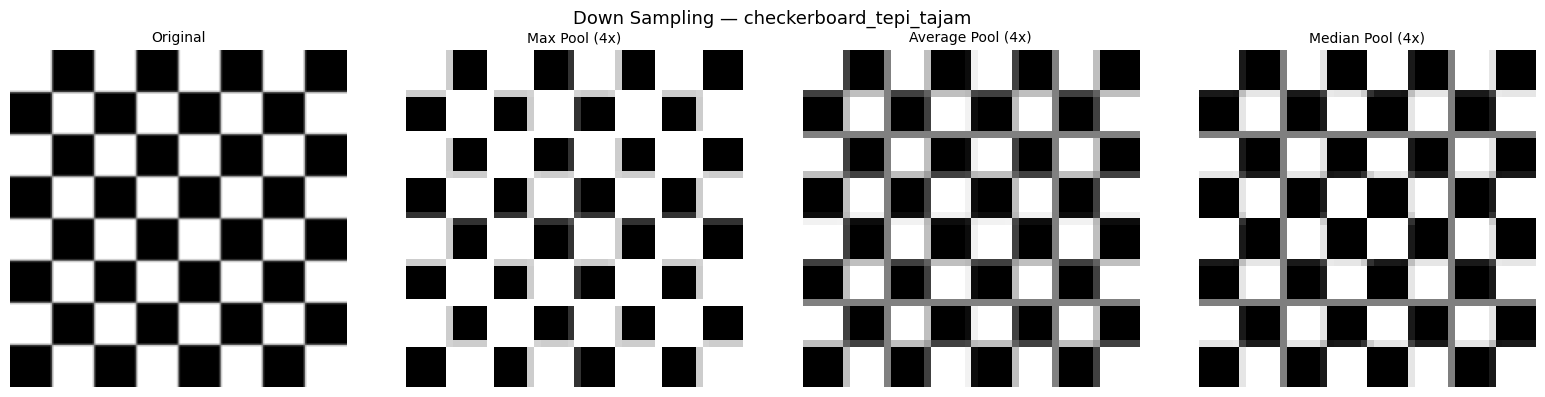

In [9]:
FACTOR = 4  #faktor downsampling

downsample_results = {}

for name, img in images.items():
    d_max = downsample_max(img, FACTOR)
    d_avg = downsample_average(img, FACTOR)
    d_med = downsample_median(img, FACTOR)

    downsample_results[name] = {"max": d_max, "average": d_avg, "median": d_med}

    show_row(
        [img, d_max, d_avg, d_med],
        ["Original", f"Max Pool ({FACTOR}x)", f"Average Pool ({FACTOR}x)", f"Median Pool ({FACTOR}x)"],
        suptitle=f"Down Sampling — {name}",
        save_name=f"{name}_downsampling.png"
    )

#Eksperimen Up Sampling

Setiap hasil down sampling (menggunakan Average Pooling sebagai representasi)
di-up sampling kembali ke ukuran asli menggunakan NN, Bilinear, dan Bicubic,
lalu dibandingkan dengan citra asli.

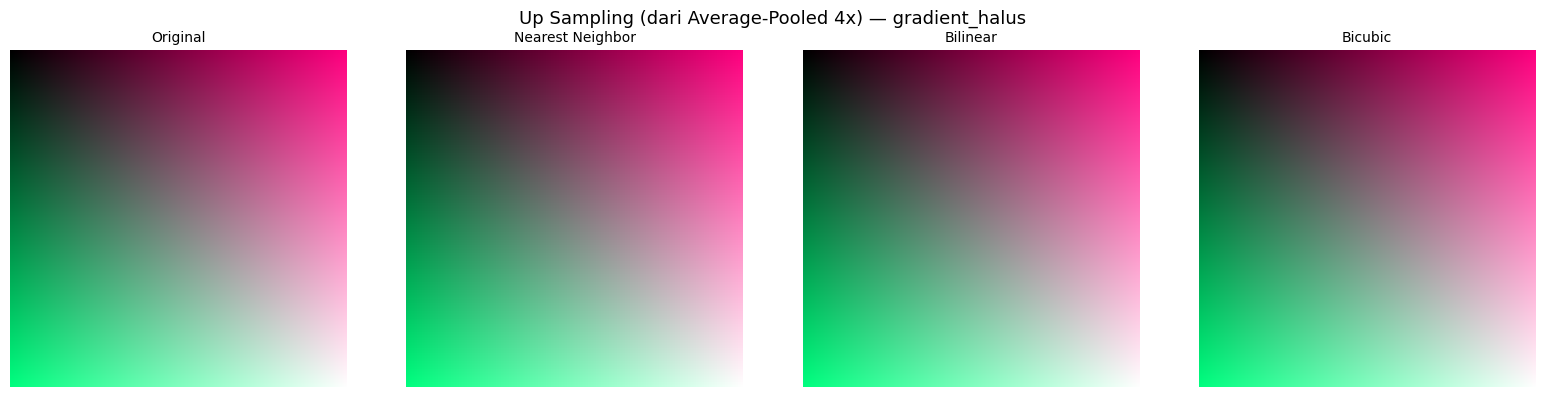

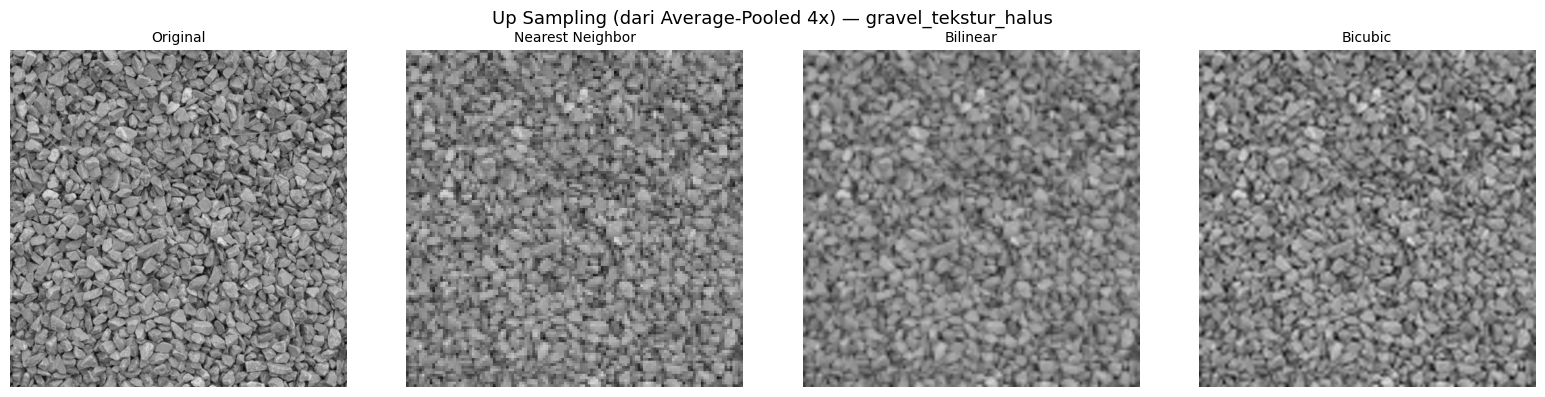

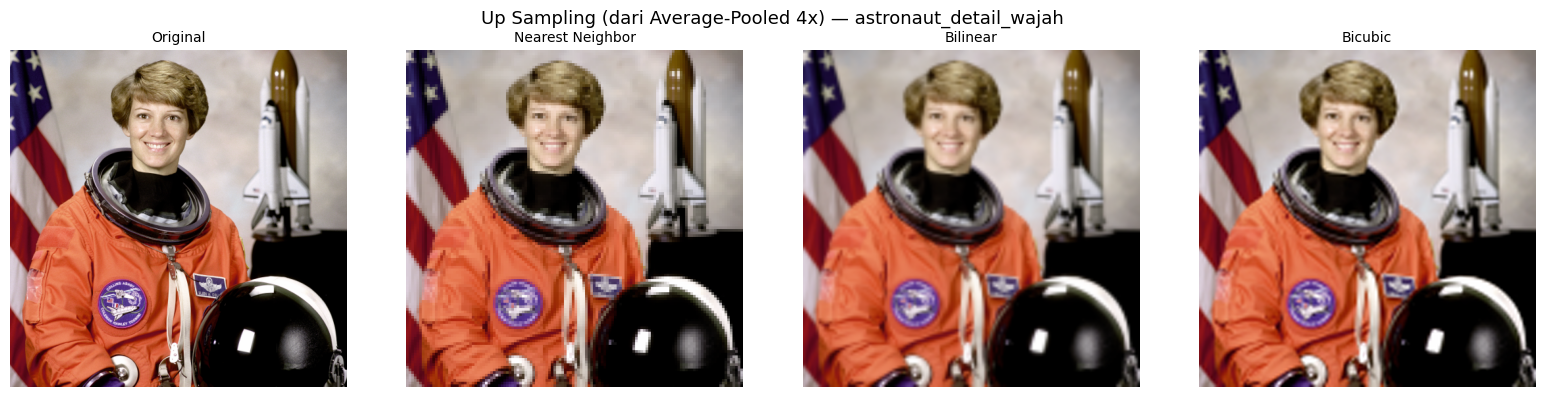

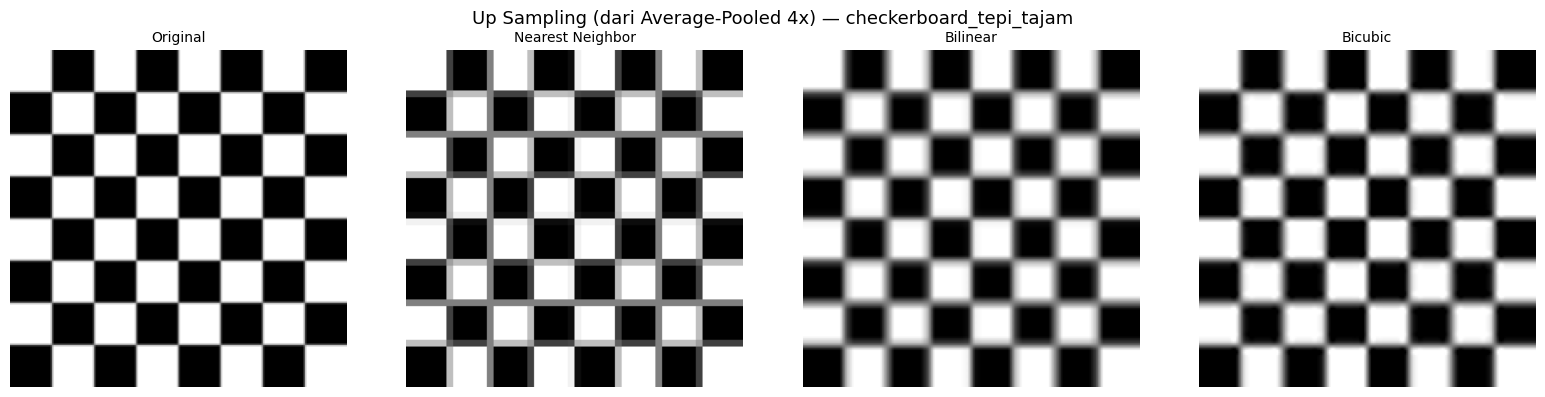

In [10]:
upsample_results = {}
metrics_table = []

for name, img in images.items():
    h, w = img.shape[:2]
    small = downsample_results[name]["average"]  #citra kecil hasil downsampling

    u_nn = upsample(small, (w, h), method='nn')
    u_bl = upsample(small, (w, h), method='bilinear')
    u_bc = upsample(small, (w, h), method='bicubic')

    upsample_results[name] = {"nn": u_nn, "bilinear": u_bl, "bicubic": u_bc}

    show_row(
        [img, u_nn, u_bl, u_bc],
        ["Original", "Nearest Neighbor", "Bilinear", "Bicubic"],
        suptitle=f"Up Sampling (dari Average-Pooled {FACTOR}x) — {name}",
        save_name=f"{name}_upsampling.png"
    )

    for method, up_img in [("NN", u_nn), ("Bilinear", u_bl), ("Bicubic", u_bc)]:
        m = compute_metrics(img, up_img)
        metrics_table.append({"Gambar": name, "Metode Upsampling": method, **m})

#Perbandingan Kuantitatif (MSE, PSNR, SSIM)

Semakin tinggi PSNR dan SSIM, dan semakin rendah MSE, semakin mirip
citra hasil upsampling dengan citra aslinya.

In [11]:
import pandas as pd

df_metrics = pd.DataFrame(metrics_table)
df_metrics = df_metrics.round(3)
df_metrics.to_csv(os.path.join(OUTPUT_DIR, "metrics_upsampling.csv"), index=False)
df_metrics

,Gambar,Metode Upsampling,MSE,PSNR,SSIM
0,gradient_halus,NN,0.415,51.950,0.993
1,gradient_halus,Bilinear,0.043,61.783,0.999
2,gradient_halus,Bicubic,0.043,61.767,0.999
3,gravel_tekstur_halus,NN,510.301,21.053,0.602
4,gravel_tekstur_halus,Bilinear,455.942,21.542,0.598
5,gravel_tekstur_halus,Bicubic,371.512,22.431,0.670
6,astronaut_detail_wajah,NN,297.480,23.396,0.783
7,astronaut_detail_wajah,Bilinear,227.027,24.570,0.809
8,astronaut_detail_wajah,Bicubic,180.252,25.572,0.839
9,checkerboard_tepi_tajam,NN,1907.114,15.327,0.708


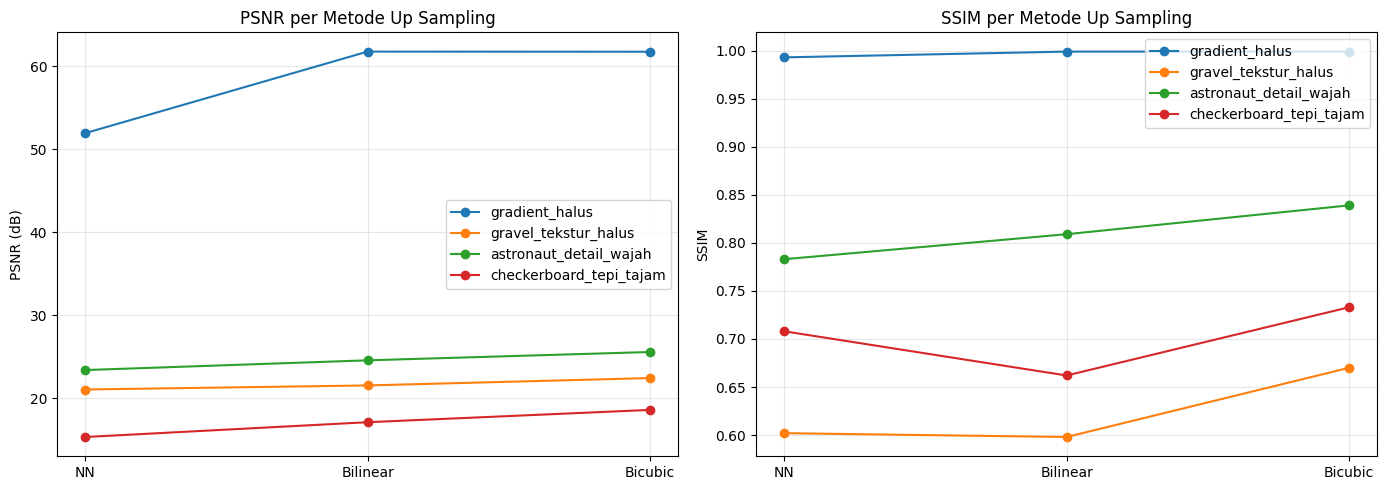

In [12]:
#Visualisasi perbandingan PSNR & SSIM per metode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in images.keys():
    subset = df_metrics[df_metrics["Gambar"] == name]
    axes[0].plot(subset["Metode Upsampling"], subset["PSNR"], marker='o', label=name)
    axes[1].plot(subset["Metode Upsampling"], subset["SSIM"], marker='o', label=name)

axes[0].set_title("PSNR per Metode Up Sampling")
axes[0].set_ylabel("PSNR (dB)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("SSIM per Metode Up Sampling")
axes[1].set_ylabel("SSIM")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "perbandingan_metrik.png"), dpi=120, bbox_inches="tight")
plt.show()

In [14]:
#Simpan gambar asli
for name, img in images.items():
    cv2.imwrite(os.path.join(OUTPUT_DIR, f"{name}_original.png"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

#Simpan hasil downsampling & upsampling individual
for name in images.keys():
    for method, im in downsample_results[name].items():
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"{name}_down_{method}.png"), cv2.cvtColor(im, cv2.COLOR_RGB2BGR))
    for method, im in upsample_results[name].items():
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"{name}_up_{method}.png"), cv2.cvtColor(im, cv2.COLOR_RGB2BGR))

import shutil
shutil.make_archive("PCD_Assignment01_outputs", 'zip', OUTPUT_DIR)
print("Selesai. File output_images/ dan PCD_Assignment01_outputs.zip siap diunduh & diupload ke GitHub.")

from google.colab import files as gfiles
gfiles.download("PCD_Assignment01_outputs.zip")

Selesai. File output_images/ dan PCD_Assignment01_outputs.zip siap diunduh & diupload ke GitHub.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Kesimpulan Singkat

- **Down sampling** mengurangi resolusi citra dengan meringkas tiap blok piksel:
  - *Max Pooling* mempertahankan piksel paling terang/menonjol → baik untuk mempertahankan tepi tajam, tetapi bisa memunculkan noise/artefak jika ada piksel outlier.
  - *Average Pooling* merata-ratakan nilai blok → hasil lebih halus, mengurangi noise, tetapi detail tajam bisa kabur.
  - *Median Pooling* mengambil nilai tengah → baik untuk meredam noise impulsif (salt-and-pepper) tanpa terlalu mengaburkan tepi.
- **Up sampling** memperbesar kembali citra kecil:
  - *Nearest Neighbor* tercepat tetapi menghasilkan efek blok/pecah-pecah (blocky/jagged edges).
  - *Bilinear* menghasilkan transisi lebih halus dengan interpolasi linear antar piksel tetangga.
  - *Bicubic* menghasilkan hasil paling halus dan tajam karena mempertimbangkan lebih banyak piksel tetangga (16 piksel), tetapi komputasinya lebih berat.